## Data Preprocessing

In this application, data preprocessing involves importing custom data, i.e., dataset that isn't part of the Keras, as a dataset, using this dataset (of type `BatchDataset`) in the application.

In [1]:
import os
import glob
import random
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.utils import image_dataset_from_directory

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Set Data Configuaration Parameters

In [3]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 10
    IMG_HEIGHT: int = 224
    IMG_WIDTH: int = 224
    NUM_CHANNELS: int = 3
    BATCH_SIZE: int = 64
    DATA_ROOT: str = "./dataset"


@dataclass(frozen=True)
class TrainingConfig:
    EPOCHS: int = 21
    LEARNING_RATE: float = 0.001
    CHECKPOINT_DIR = "./saved_models"

In [4]:
datasetConfig = DatasetConfig()
trainingConfig = TrainingConfig()

In [5]:
# Set data paths
train_path = os.path.join(datasetConfig.DATA_ROOT, "train")
valid_path = os.path.join(datasetConfig.DATA_ROOT, "valid")

### Print class names

In [6]:
classNames = sorted([f for f in os.listdir(train_path) if not f.startswith(".")])

print("Classnames: ")
for i in range(len(classNames)):
    print(i, classNames[i])

Classnames: 
0 baseball
1 basketball
2 beachballs
3 billiard ball
4 bowling ball
5 brass
6 buckeyballs
7 cannon ball
8 cricket ball
9 eyeballs


### Data Visualisation

In [7]:
def getAllImagePaths(directoryName):
    return glob.glob(f"{directoryName}/*/*", recursive=True)

In [8]:
def displayDatasetSamples(imagePaths):
    plt.figure(figsize=(18, 12))
    numRows = 5
    numCols = 8

    for i in range(numRows * numCols):
        plt.subplot(numRows, numCols, i + 1)

        # Generate a random index.
        idx = random.choice(list(range(0, len(imagePaths))))
        img = plt.imread(imagePaths[idx])
        label = imagePaths[idx].split("/")[-2]
        plt.imshow(img)
        plt.axis("off")
        plt.title(label)

    plt.show(block=False)

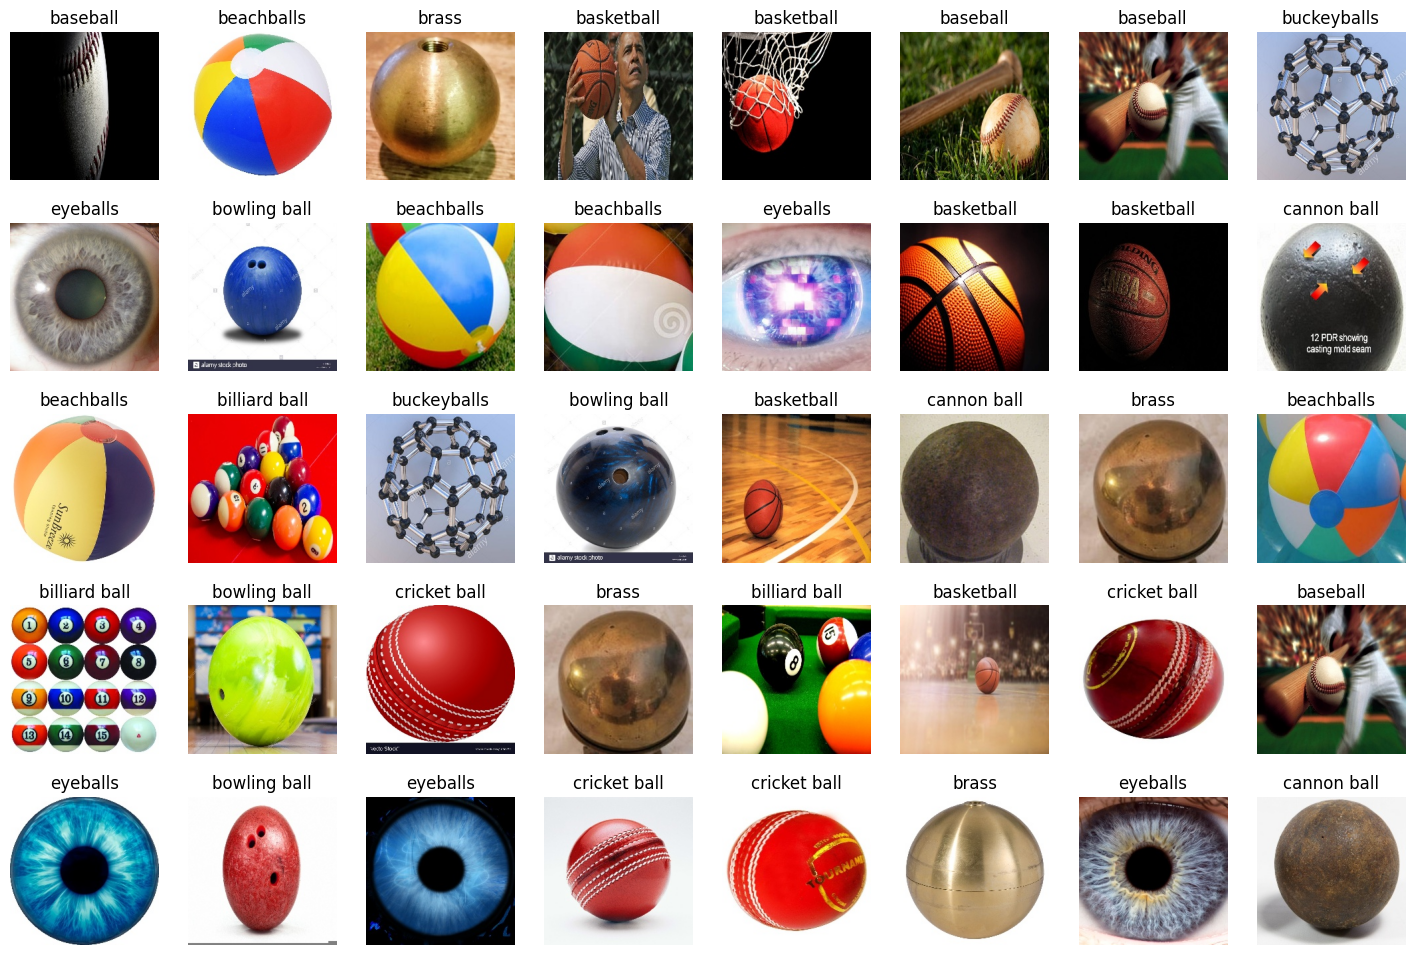

In [9]:
imagePaths = getAllImagePaths(train_path)

displayDatasetSamples(imagePaths)

### Create `BatchDataset` Objects

**Note**: One important input argument is the `batch_size` of the data. This is defaulted to **32**, but regardless of the value, it's important to note that when we use a `BatchDataset` object, there is no need to specify a "batch_size" for training in the `Model.fit()` method since the `BatchDataset` object has already been partitioned into batches.

The `label_mode` argument is also set so that it will one-hot encode the class labels as well as a `seed` value for repeatability since the data is first shuffled before creating the `BatchDataset` objects (note: `shuffle` is defaulted to True).

In [10]:
input_shape = (datasetConfig.IMG_HEIGHT, datasetConfig.IMG_WIDTH)

train_dataset = image_dataset_from_directory(
    directory=train_path,
    batch_size=datasetConfig.BATCH_SIZE,
    image_size=input_shape,
    label_mode="categorical",
    seed=SEED,
)

valid_dataset = image_dataset_from_directory(
    directory=valid_path,
    batch_size=datasetConfig.BATCH_SIZE,
    image_size=input_shape,
    label_mode="categorical",
    seed=SEED,
)

Found 1125 files belonging to 10 classes.
Found 200 files belonging to 10 classes.


In [11]:
# Access batches from the BatchDataset object
for data_batch, labels_batch in train_dataset:
    print(f"Data batch shape: {data_batch.shape}")
    print(f"Labels batch shape: {labels_batch.shape}")
    break

# Batches can also be retrived using the take()
for data_batch, labels_batch in train_dataset.take(1):
    print(f"Take() Data batch shape: {data_batch.shape}")
    print(f"Take() Labels batch shape: {labels_batch.shape}")

Data batch shape: (64, 224, 224, 3)
Labels batch shape: (64, 10)
Take() Data batch shape: (64, 224, 224, 3)
Take() Labels batch shape: (64, 10)


2025-11-21 23:35:12.050353: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
# List the classnames in the dataset
classNames = train_dataset.class_names
print(classNames)

['baseball', 'basketball', 'beachballs', 'billiard ball', 'bowling ball', 'brass', 'buckeyballs', 'cannon ball', 'cricket ball', 'eyeballs']


### Data Visualisation using `BatchDataset`

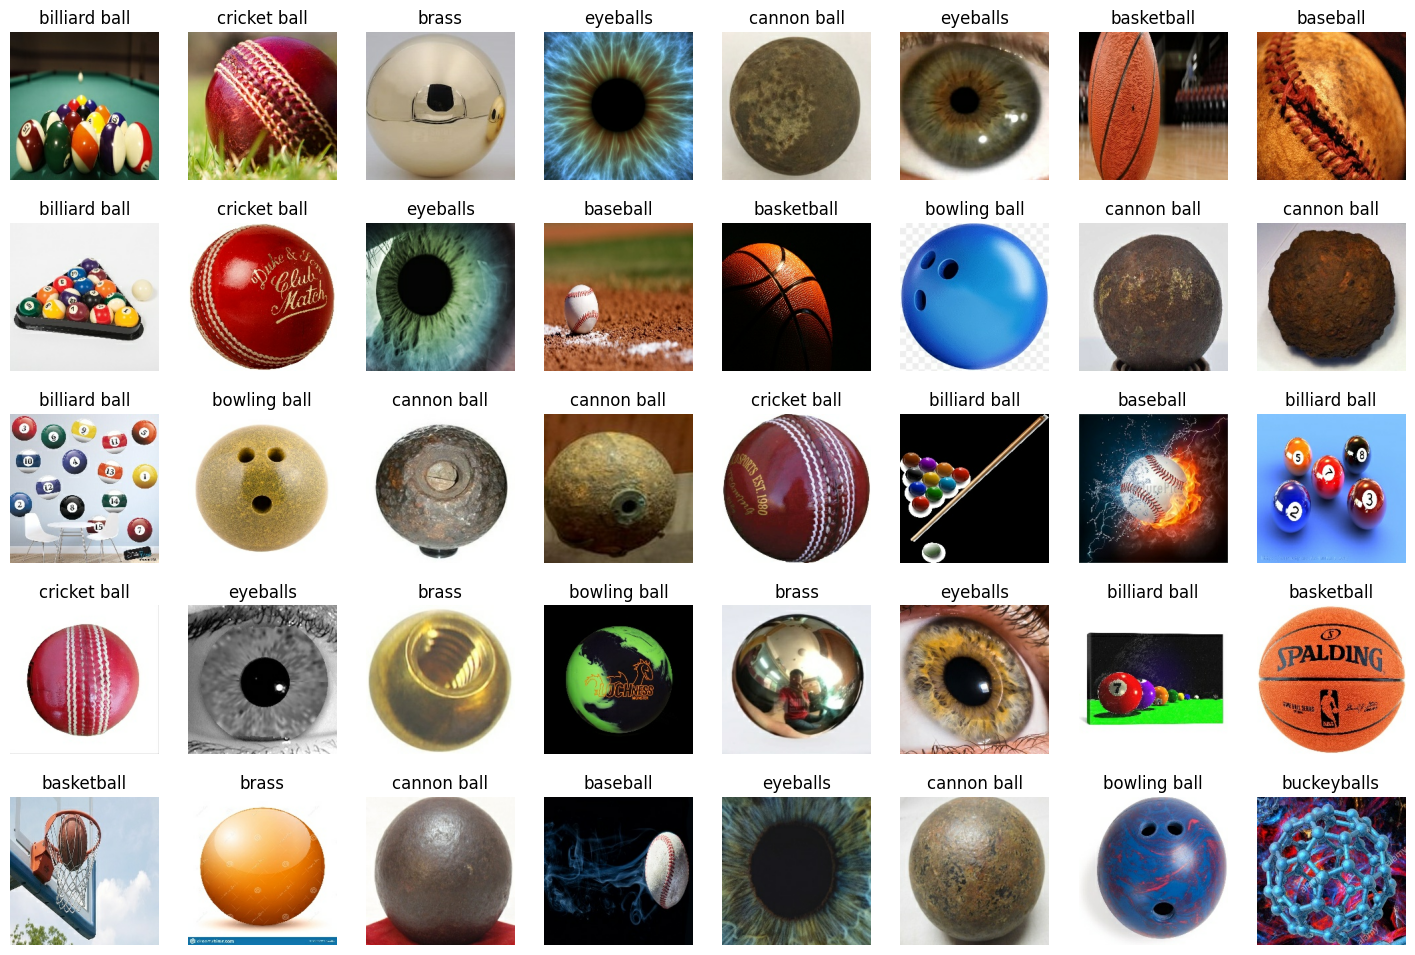

2025-11-21 23:36:22.131744: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
plt.figure(figsize=(18, 12))
numRows = 5
numCols = 8

for data_batch, labels_batch in train_dataset.take(1):
    # For the batch of images and the associated (one-hot encoded) labels,
    # plot each of the images in the batch and the associated ground truth labels.
    for i in range(numRows * numCols):
        ax = plt.subplot(numRows, numCols, i + 1)
        plt.imshow(data_batch[i].numpy().astype("uint8"))
        truth_idx = np.nonzero(labels_batch[i].numpy())
        plt.title(classNames[truth_idx[0][0]])
        plt.axis("off")
        plt.subplot(numRows, numCols, i + 1)

    plt.show(block=False)